In [1]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from confidence.unsupervised.classic.SHE import SHETorchConfidence
from confidence.unsupervised.classic.dice import DICEConfidence
from confidence.unsupervised.classic.lof import LOFTorchConfidence
from model.classifier import Classifier, MyProgressBar
from utils.transforms.apply import grid_resample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#look for experiment files in parents
import os
path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)


In [3]:
experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")

In [4]:
from utils.affine_transforms import AffineTransformation2D
from dataset.mnist_no_pil import NoPILMNIST, NoPILFashionMNIST, AffineTransformDataset

dataset = 'mnist' # or 'fmnist'
batch_size = 128
#divide by 255 transform


if dataset == 'mnist':
    # essentially excluding either 6 or 9 as these would cause degenerations under 180 degree rotation
    dataset_train = NoPILMNIST(experiment_files_path_data,train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILMNIST(experiment_files_path_data,train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.
elif dataset == 'fmnist':
    dataset_train = NoPILFashionMNIST(experiment_files_path_data,train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILFashionMNIST(experiment_files_path_data,train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.



transformations = [AffineTransformation2D.ROTATION.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi,torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]

#test simulated annealing
from utils.transformation_problem import TransformationProblem
from utils.transform_sequence import TransformSequence, create_parameter_sampler, create_sampler

transform_seq= TransformSequence(transformations, domains, neighbour_hood_size =0.0,application_method=grid_resample,device="cpu",reflect=True,use_individual_param_correction=False)

sampler = create_sampler(transform_seq)

dataset_test = AffineTransformDataset(dataset_test_pre,sampler,return_transformation=False,batch_size=batch_size)

transform_seq.to(device)


TransformSequence()

In [5]:
dataset_train_transformed = AffineTransformDataset(dataset_train,sampler,return_transformation=False,batch_size=batch_size)
train_loader_transformed = torch.utils.data.DataLoader(dataset_train_transformed, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)

In [6]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)

In [7]:
dataset_val_transformed = AffineTransformDataset(dataset_val,sampler,return_transformation=False,batch_size=batch_size)

val_loader_transformed = torch.utils.data.DataLoader(dataset_val_transformed, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)

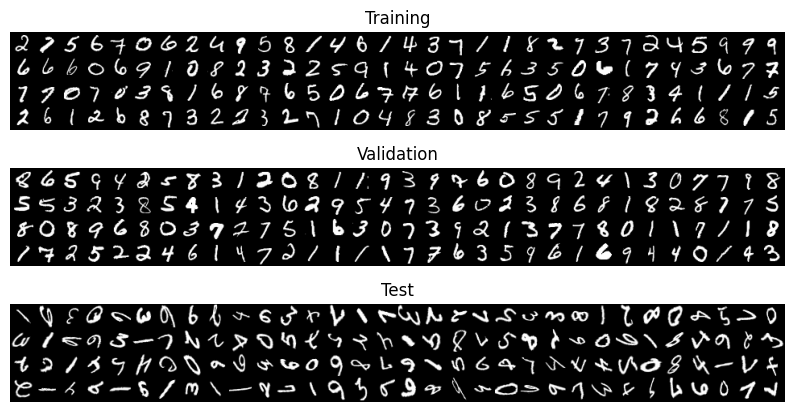

In [8]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [9]:
modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric.pth")

In [10]:
import pytorch_lightning as pl
import os
from pytorch_lightning.callbacks import ModelCheckpoint

model_path = modelpath

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(64),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, 10)
)


# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class =  torch.optim.AdamW, optimizer_params = {"lr": 1e-3})
    progress_bar = MyProgressBar()

    checkpoint_callback = ModelCheckpoint(
        monitor='val_acc',
        mode='max',
        save_top_k=1,
        verbose=True,
        dirpath=os.path.join(os.getcwd(), "model"),
        filename=f"{dataset}_val_acc_best"
    )
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[progress_bar, checkpoint_callback],
    )

    # Train the model
    trainer.fit(lightning_model, train_loader,val_loader)

    best_ckpt = checkpoint_callback.best_model_path
    print(f"Best Lightning checkpoint: {best_ckpt}")

    lightning_model = Classifier.load_from_checkpoint(
        best_ckpt,
        model=model,  # supply same nn.Sequential structure
        optimizer_class=torch.optim.AdamW,
        optimizer_params={"lr": 1e-3}
    )

    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

Loading model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\mnist_metric.pth


In [11]:
#calibrate the model
#from confidence.calibration import TemperatureCalibrationModule
#if model is not temperature calibrated
#if isinstance(model, TemperatureCalibrationModule):
    #model = model.model
#model = TemperatureCalibrationModule(model,per_logit=True).cuda()
#model.fit(test_loader)


In [12]:
model.cuda().eval()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=3136, out_features=128, bias=True)
  (10): Dropout(p=0.5, inplace=False)
  (11): GELU(approximate='none')
  (12): Linear(in_features=128, out_features=10, bias=True)
)

In [13]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')

Mean accuracy on the val set: 0.9924.


In [14]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

Mean accuracy on the transformed test set: 0.4102.


In [15]:
from pytorch_lightning.callbacks import ModelCheckpoint
import pytorch_lightning as pl
import os
import torch
import torch.nn as nn

modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric3.pth")
model_path = modelpath

model2 = nn.Sequential(
    nn.Conv2d(1, 128, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(128),
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(256),
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(256),
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(256 * 3 * 3, 128),
    torch.nn.Dropout(0.5),
    nn.GELU(),
    nn.Linear(128, n_classes)
)

if os.path.exists(model_path) and True:
    print(f"Loading model from {model_path}")
    model2.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")

    # LightningModule wrapper
    lightning_model = Classifier(
        model2,
        optimizer_class=torch.optim.AdamW,
        optimizer_params={"lr": 1e-3}
    )

    # Callbacks
    progress_bar     = MyProgressBar()
    checkpoint_callback = ModelCheckpoint(
        monitor='val_acc',
        mode='max',
        save_top_k=1,
        verbose=True,
        dirpath=os.path.join(os.getcwd(), "model"),
        filename=f"{dataset}_val_acc_best"
    )

    # Trainer
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[progress_bar, checkpoint_callback],
    )

    # Train
    trainer.fit(lightning_model, train_loader_transformed, val_loader_transformed)

    # 1) Reload LightningModule from best ckpt
    best_ckpt = checkpoint_callback.best_model_path
    print(f"Best Lightning checkpoint: {best_ckpt}")

    lightning_model = Classifier.load_from_checkpoint(
        best_ckpt,
        model=model2,  # supply same nn.Sequential structure
        optimizer_class=torch.optim.AdamW,
        optimizer_params={"lr": 1e-3}
    )

    # 2) Extract & save raw nn.Sequential weights
    model2.load_state_dict(lightning_model.model.state_dict())
    torch.save(model2.state_dict(), model_path)
    print(f"Best model saved to {model_path}")


with torch.no_grad():
    model2.cuda().eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model2(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the test set: {test_acc}.')

model2 = None
torch.cuda.empty_cache()


Loading model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\mnist_metric3.pth
Mean accuracy on the test set: 0.9414.


In [16]:
model42 =torch.nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(64),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 32x14x14
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(128),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(128 * 7 * 7, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, n_classes)
)

In [17]:
from experiment_thesis.main import train_and_get_model

In [18]:
modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric2.pth")
import pytorch_lightning as pl
import os

model_path = modelpath

model2 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(64),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, n_classes)
)

if os.path.exists(model_path) and True:
    print(f"Loading model from {model_path}")
    model2.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")

    # LightningModule wrapper
    lightning_model = Classifier(
        model2,
        optimizer_class=torch.optim.AdamW,
        optimizer_params={"lr": 1e-3}
    )

    # Callbacks
    progress_bar     = MyProgressBar()
    checkpoint_callback = ModelCheckpoint(
        monitor='val_acc',
        mode='max',
        save_top_k=1,
        verbose=True,
        dirpath=os.path.join(os.getcwd(), "model"),
        filename=f"{dataset}_val_acc_best"
    )

    # Trainer
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[progress_bar, checkpoint_callback],
    )

    # Train
    trainer.fit(lightning_model, train_loader_transformed, val_loader_transformed)

    # 1) Reload LightningModule from best ckpt
    best_ckpt = checkpoint_callback.best_model_path
    print(f"Best Lightning checkpoint: {best_ckpt}")

    lightning_model = Classifier.load_from_checkpoint(
        best_ckpt,
        model=model2,  # supply same nn.Sequential structure
        optimizer_class=torch.optim.AdamW,
        optimizer_params={"lr": 1e-3}
    )

    # 2) Extract & save raw nn.Sequential weights
    model2.load_state_dict(lightning_model.model.state_dict())
    torch.save(model2.state_dict(), model_path)
    print(f"Best model saved to {model_path}")

with torch.no_grad():
    model2.cuda().eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model2(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')


model2 = None
torch.cuda.empty_cache()

Loading model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\mnist_metric2.pth
Mean accuracy on the transformed test set: 0.929.


In [19]:
from confidence.utils import ModelInputWrapper

#use model wrapper to extract the embeddings
dual_ouput_model = ModelInputWrapper(model,'10',flatten=True).eval()

In [20]:
#extract embeddings and fit NNDistanceConfidence()
embeddings=[]
classes =[]
from confidence.direct.logit_based import EnergyConfidence
energy_conf_module = EnergyConfidence()

logits = []

for batch in train_loader:
    emb,logit = dual_ouput_model(batch[0].cuda())
    embeddings.append(emb.detach().cpu().numpy())
    classes.append(batch[1].detach().cpu().numpy())
    logits.append(logit.detach().cpu().numpy())


embeddings = np.vstack(embeddings)
classes = np.hstack(classes)
logits = np.vstack(logits)
#randomly sample 5000 ones
if embeddings.shape[0] > 5000:
    indices = np.random.choice(embeddings.shape[0], 5000, replace=False)
    embeddings_sampled = embeddings[indices]
    classes_sampled = classes[indices]
    logits_sampled = logits[indices]
else:
    embeddings_sampled = embeddings
    classes_sampled = classes
    logits_sampled = logits


In [21]:
from torch.utils.data.sampler import (
    BatchSampler,
    RandomSampler,
    Sampler,
    SequentialSampler,
)

In [22]:
model

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=3136, out_features=128, bias=True)
  (10): Dropout(p=0.5, inplace=False)
  (11): GELU(approximate='none')
  (12): Linear(in_features=128, out_features=10, bias=True)
)

In [24]:
from embedding_cache import LayerEmbeddingCache


orig_sampler =train_loader.batch_sampler.sampler
train_loader.batch_sampler.sampler = SequentialSampler(dataset_train)
cache = LayerEmbeddingCache(model,train_loader,cache_dir="test2",dataset_fp_batches=100)
embeddings_t,final_t,classes_t = cache.__call__("12",capture_modes='input')
train_loader.batch_sampler.sampler = orig_sampler

Computing embeddings: 100%|██████████| 469/469 [00:00<00:00, 550.62batch/s]


In [25]:
import search.shgo
import importlib
importlib.reload(search.shgo)

<module 'search.shgo' from 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\search\\shgo.py'>

In [26]:
di = search.shgo.SHGO(selection_method="topk")
di_no_grad = search.shgo.SHGO(selection_method="topk",local_max_steps=0)

In [27]:
def evaluate_conf(model, di, problem, test_loader, max_batch_override=None):
    if max_batch_override is not None:
        problem.max_batch_size = max_batch_override
    with torch.no_grad():
        test_acc_sim = 0
        counter = 0
        pbar = tqdm.tqdm(test_loader, desc="Evaluating confidence", unit="batch")
        for data, target in pbar:
            data, target = data.cuda(), target.cuda()
            with torch.enable_grad():
                res = di.optimize(problem, data.cuda(), y=None)
                res = list(res)
            torch.cuda.empty_cache()
            res[0] = res[0].detach()  # Detach the result to avoid gradients
            res[1] = res[1].detach()  # Detach the result to avoid gradients
            # Apply the transformation and get predictions
            x_transformed2 = problem.transform(data.cuda(), res[0])
            logits = model(x_transformed2)
            output = logits.argmax(dim=-1)
            test_acc_sim += output.eq(target).sum().cpu().detach().item()
            counter += output.shape[0]
            #update progress bar
            pbar.set_postfix({"accuracy": test_acc_sim / counter})

    test_acc_sim /= counter
    return test_acc_sim


import tqdm

from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence

conf_mod_nn_pytorch = SinglePassConfidence(model, EnergyConfidence())
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch, transform_seq, consolidate_method="consolidate_simple")
evaluate_conf(model, di, problem_nn_pytorch, test_loader, max_batch_override=1280)

Evaluating confidence: 100%|██████████| 40/40 [00:19<00:00,  2.02batch/s, accuracy=0.773]


0.773

In [29]:
from utils.eval.ood_performance import evaluate_confidence_and_search,evaluate_confidence_module

In [30]:
di2 = search.shgo.SHGO(selection_method="topk")

In [31]:
evaluate_confidence_and_search(model, di2, problem_nn_pytorch, test_loader, max_batch_override=1280)

{'repeats': 1,
 'accuracy_mean': 0.7734000086784363,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.7572440505027771,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.7734000086784363,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.7608843445777893,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.7734000086784363,
   'f2_macro': 0.7572440505027771,
   'f2_micro': 0.7734000086784363,
   'f2_weighted': 0.7608843445777893,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': [True,
    False,
    True,
    True,
    True,
    False,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    False,
    True,
    False,
    True,
    True,
    True,
    False,
    True,
    False,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    True,
    False,
    True,
    True,
   

In [32]:
list(model.named_modules())

[('',
  Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=3136, out_features=128, bias=True)
    (10): Dropout(p=0.5, inplace=False)
    (11): GELU(approximate='none')
    (12): Linear(in_features=128, out_features=10, bias=True)
  )),
 ('0', Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))),
 ('1',
  BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)),
 ('2

In [33]:
filter_correct = True  # Set to False to include all samples
embeddings22 = []
images22 = []
classes22 = []
logits22 = []
from confidence.utils import ModelInputOutputWrapper
dual_ouput_model22 = ModelInputOutputWrapper(model,"12",capture_modes=["input"])

for data, target in train_loader:
    data_cuda = data.cuda()
    emb_batch,logits_batch = dual_ouput_model22(data_cuda)
    #emb_batch2 = model[:-1](data_cuda)
    #assert torch.allclose(emb_batch, emb_batch2), "Embeddings do not match between models."
    emb_batch = emb_batch.detach().cpu().numpy()
    target_np = target.numpy()

    if filter_correct:
        mask = target_np == logits_batch.argmax(dim=-1).cpu().numpy()
        emb_np = emb_batch[mask]
        class_np = target_np[mask]
    else:
        emb_np = emb_batch.detach().cpu().numpy()
        class_np = target_np

    embeddings22.append(emb_np)
    classes22.append(class_np)

embeddings22 = np.vstack(embeddings22)
classes22 = np.hstack(classes22)







from confidence.control.classify import ClassifyingConfidence
from confidence.unsupervised.classic.VIM import ViMTorchConfidence
gmm_conf = ViMTorchConfidence(model.eval(),n_dim=32,use_energy=True)
gmm_conf.fit(torch.tensor(embeddings22).cuda(),y=torch.tensor(classes22).cuda())
gmm_conf.cuda()

conf_split = ClassifyingConfidence(gmm_conf,index=1,index_confidence=0)
gmm_conf = SinglePassConfidence(dual_ouput_model22, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 40/40 [00:19<00:00,  2.07it/s]

Mean accuracy on the transformed test set with GD: 0.912.


In [34]:


from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
nn_pytorch = KNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings_sampled).cpu())
nn_pytorch.cuda()


conf_split = SplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.0)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.9488.


In [39]:


from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence,PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence,PerClassKNNConfidence
nn_pytorch = PerClassKNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings_sampled).cpu(), torch.tensor(classes_sampled).cpu())
nn_pytorch.cuda()


conf_split = PredictedSplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.0)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=None)

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.952.


In [45]:

#extract logits from train
logits2 = []
classes2 = []
for batch in train_loader:
    logits_batch = model(batch[0].cuda())
    logits2.append(logits_batch.detach().cpu().numpy())
    classes2.append(batch[1].detach().cpu().numpy())
logits2 = np.vstack(logits2)
classes2 = np.hstack(classes2)




from confidence.unsupervised.classic.kl_matching import KLMatchingConfidence

gmm_conf = KLMatchingConfidence()
gmm_conf.fit(torch.tensor(logits2).cuda(),y=torch.tensor(classes2).cuda())
gmm_conf.cuda()
gmm_conf = SinglePassConfidence(model, gmm_conf)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 40/40 [00:28<00:00,  1.40it/s]

Mean accuracy on the transformed test set with GD: 0.1128.


In [40]:
dfhds

NameError: name 'dfhds' is not defined

In [26]:
import tqdm

from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
nn_pytorch = KNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings).cpu())
nn_pytorch.cuda()


conf_split = SplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.0000)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

evaluate_conf(model, di, problem_nn_pytorch, test_loader)

Evaluating confidence: 100%|██████████| 40/40 [00:15<00:00,  2.52batch/s, accuracy=0.942]


0.942

In [27]:
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
nn_pytorch = KNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings).cpu())
nn_pytorch.cuda()
split_conf = SplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.0)

conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,split_conf,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

evaluate_conf(model, di_no_grad, problem_nn_pytorch, test_loader)



Evaluating confidence: 100%|██████████| 40/40 [00:10<00:00,  3.78batch/s, accuracy=0.929]


0.9286

In [28]:
#extract output tuples from val_loader, and val_transformed loader
complex_outputs = []
complex_y = []
import optree
with torch.no_grad():
    for batch in val_loader:
        logits_batch = dual_ouput_model(batch[0].cuda())
        #logits_batch = model(batch[0].cuda())
        p_c = logits_batch[-1].argmax(dim=-1)
        filter = p_c == batch[-1].cuda()
        #filter = torch.ones_like(p_c, dtype=torch.bool)

        complex_outputs.append(optree.tree_map(lambda x: x[filter], logits_batch))
        complex_y.append(batch[1].cuda()[filter])

    import optree
    val_outputs = optree.tree_map(lambda x: x.cpu(), complex_outputs)
    val_y = optree.tree_map(lambda x: x.cpu(), complex_y)
    #stack using optree
    val_outputs = optree.tree_map(lambda *x: torch.cat(x, dim=0), *val_outputs)
    val_y = optree.tree_map(lambda *x: torch.cat(x, dim=0), *val_y)




In [29]:
#repeat for val_loader_transformed
complex_outputs_transformed = []
complex_y_transformed = []
with torch.no_grad():
    for batch in val_loader_transformed:
        logits_batch = dual_ouput_model(batch[0].cuda())
        #logits_batch = model(batch[0].cuda())
        p_c = logits_batch[-1].argmax(dim=-1)
        filter = p_c != batch[-1].cuda()
        #filter = torch.ones_like(p_c, dtype=torch.bool)
        #filter only values that have the true class lower than a specific threshold



        complex_outputs_transformed.append(optree.tree_map(lambda x: x[filter], logits_batch))
        complex_y_transformed.append(batch[1].cuda())
    import optree
    val_outputs_transformed = optree.tree_map(lambda x: x.cpu(), complex_outputs_transformed)
    val_y_transformed = optree.tree_map(lambda x: x.cpu(), complex_y_transformed)
    #stack using optree
    val_outputs_transformed = optree.tree_map(lambda *x: torch.cat(x, dim=0), *val_outputs_transformed)
    val_y_transformed = optree.tree_map(lambda *x: torch.cat(x, dim=0), *val_y_transformed)



In [30]:
from torch.utils.data import Dataset
class SingleItemDataset(Dataset):
    def __init__(self, outputs, labels):
        self.outputs = outputs
        self.labels = labels

    def __len__(self):
        # assume all output leaves share the first dimension
        first_leaf = next(iter(optree.tree_leaves(self.outputs)))
        return first_leaf.shape[0]

    def __getitem__(self, idx):
        item_out   = optree.tree_map(lambda x: x[idx], self.outputs)
        item_label = optree.tree_map(lambda x: x[idx], self.labels)
        return item_out, item_label

In [31]:
from torch.utils.data import DataLoader

#define a dataloader for the transformed validation set
custom_dataset = SingleItemDataset(val_outputs, val_y)
custom_dataloader_val = DataLoader(custom_dataset, batch_size=128, shuffle=False)
custom_dataset_val_transformed = SingleItemDataset(val_outputs_transformed, val_y_transformed)
custom_dataloader_val_transformed  = DataLoader(custom_dataset_val_transformed, batch_size=128, shuffle=False)

In [32]:
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence

import importlib
import confidence.control.regression
importlib.reload(confidence.control.regression)
from confidence.control.regression import RegressionConfidence

#ideas to make this work, normalize the oututted ocnfidence values, wieght the loss due to overlap of the sets

split_reg = RegressionConfidence((nn_pytorch,EnergyConfidence()),epochs=1000,pos_weight=1,scaler="standardize",lr=1e-1,verbose=50).cuda()

split_reg.fit(in_loader=custom_dataloader_val, out_loader=custom_dataloader_val_transformed)

conf_mod_nn_pytorch_reg = SinglePassConfidence(dual_ouput_model,split_reg,index=1)
problem_nn_pytorch_reg = TransformationProblem(conf_mod_nn_pytorch_reg,transform_seq,consolidate_method="consolidate_simple")



evaluate_conf(model, di_no_grad, problem_nn_pytorch_reg, test_loader)

Epoch 0: Loss = 0.544916
Epoch 50: Loss = 0.125929
Epoch 100: Loss = 0.117565
Epoch 150: Loss = 0.112568
Epoch 200: Loss = 0.109981
Epoch 250: Loss = 0.108745
Epoch 300: Loss = 0.108175
Epoch 350: Loss = 0.107920
Epoch 400: Loss = 0.107810
Epoch 450: Loss = 0.107765
Epoch 500: Loss = 0.107747
Epoch 550: Loss = 0.107740
Epoch 600: Loss = 0.107738
Epoch 650: Loss = 0.107737
Epoch 700: Loss = 0.107737
Epoch 750: Loss = 0.107737
Epoch 800: Loss = 0.107737
Epoch 850: Loss = 0.107737
Epoch 900: Loss = 0.107737
Epoch 950: Loss = 0.107737


Evaluating confidence: 100%|██████████| 40/40 [00:10<00:00,  3.76batch/s, accuracy=0.924]


0.9242

In [33]:
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence

import importlib
import confidence.control.regression
importlib.reload(confidence.control.regression)
from confidence.control.regression import RegressionConfidence

#ideas to make this work, normalize the oututted ocnfidence values, wieght the loss due to overlap of the sets
#aggregator =torch.nn.Linear(2,1)
aggregator = torch.nn.Sequential(
    torch.nn.Linear(2, 32),
    torch.nn.GELU(),
    torch.nn.Linear(32, 1)
)

split_reg = RegressionConfidence((nn_pytorch,EnergyConfidence()),epochs=1000,pos_weight=1,scaler="standardize",aggregator=aggregator,lr=1e-2).cuda()

split_reg.fit(in_loader=custom_dataloader_val, out_loader=custom_dataloader_val_transformed)

conf_mod_nn_pytorch_reg = SinglePassConfidence(dual_ouput_model,split_reg,index=1)
problem_nn_pytorch_reg = TransformationProblem(conf_mod_nn_pytorch_reg,transform_seq,consolidate_method="consolidate_simple")



evaluate_conf(model, di, problem_nn_pytorch_reg, test_loader)

Evaluating confidence: 100%|██████████| 40/40 [00:15<00:00,  2.55batch/s, accuracy=0.936]


0.936

In [34]:
class FlexibleAggregator(nn.Module):
    """
    Aggregator that allows each input score to be processed by its own
    feature extractor network and then combines them via a linear layer.

    Args:
        k: number of input scores
        feature_extractors: list of nn.Module, length k, each network processes one score
        bias: whether the final linear layer has a bias
    """
    def __init__(self, k: int, feature_extractors: list = None, bias: bool = True):
        super().__init__()
        self.k = k

        # If no feature_extractors are provided, default to identity (just scale)
        if feature_extractors is None:
            self.feature_extractors = nn.ModuleList([nn.Identity() for _ in range(k)])
        else:
            assert len(feature_extractors) == k, "Length of feature_extractors must equal k"
            self.feature_extractors = nn.ModuleList(feature_extractors)

        # Linear combiner to get final score
        self.combiner = nn.Linear(k, 1, bias=bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [batch_size, k] input scores
        returns: [batch_size] combined score
        """
        # Apply each feature extractor (vectorized over batch)
        transformed = [self.feature_extractors[i](x[:, i:i+1]) for i in range(self.k)]
        # Stack back into [batch_size, k]
        transformed = torch.cat(transformed, dim=1)
        # Linear combination
        out = self.combiner(transformed).view(-1)
        return out

from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence

import importlib
import confidence.control.regression
importlib.reload(confidence.control.regression)
from confidence.control.regression import RegressionConfidence

#ideas to make this work, normalize the oututted ocnfidence values, wieght the loss due to overlap of the sets
#aggregator =torch.nn.Linear(2,1)
aggregator = FlexibleAggregator(
    k=2,
    feature_extractors=[
        nn.Sequential(
            torch.nn.Linear(1, 32),
            torch.nn.GELU(),
            torch.nn.Linear(32, 1)
        ),
        nn.Sequential(
            torch.nn.Linear(1, 32),
            torch.nn.GELU(),
            torch.nn.Linear(32, 1)
        )
    ]
)

split_reg = RegressionConfidence((nn_pytorch,EnergyConfidence()),epochs=1000,pos_weight=1,scaler="standardize",aggregator=aggregator,lr=1e-2).cuda()

split_reg.fit(in_loader=custom_dataloader_val, out_loader=custom_dataloader_val_transformed)

conf_mod_nn_pytorch_reg = SinglePassConfidence(dual_ouput_model,split_reg,index=1)
problem_nn_pytorch_reg = TransformationProblem(conf_mod_nn_pytorch_reg,transform_seq,consolidate_method="consolidate_simple")



evaluate_conf(model, di, problem_nn_pytorch_reg, test_loader)

Evaluating confidence: 100%|██████████| 40/40 [00:15<00:00,  2.54batch/s, accuracy=0.941]


0.941

In [35]:
aggregator.combiner.weight.data[0,1]=0
evaluate_conf(model, di, problem_nn_pytorch_reg, test_loader)

Evaluating confidence: 100%|██████████| 40/40 [00:16<00:00,  2.47batch/s, accuracy=0.941]


0.9408

In [36]:
transform_seq_neg_sample = TransformSequence(
    transformations=transform_seq.transformations,
    domains=transform_seq.domains,
    neighbour_hood_size=transform_seq.neighbour_hood_size,
    application_method=transform_seq.application_method,
    device=transform_seq.device,
    init_method = "individual",

)

In [2]:
import torch
import torch.nn.functional as F
import kornia

def augment_true(images, max_shift=1.0, max_angle=3.0, max_scale=0.04):
    B, C, H, W = images.shape
    device = images.device

    # random translations in pixels
    translations = torch.empty(B, 2, device=device).uniform_(-max_shift, max_shift)

    # random angles in radians
    angles = torch.empty(B, device=device).uniform_(-max_angle, max_angle)

    # random scales
    scales = 1.0 + torch.empty(B, device=device).uniform_(-max_scale, max_scale)
    scales = scales.unsqueeze(1).repeat(1, 2)

    # center of image
    center = torch.tensor([[W / 2, H / 2]], device=device).expand(B, -1)

    # get 3x3 affine matrices in pixel coordinates
    M_3x3 = kornia.geometry.transform.get_affine_matrix2d(translations, center, scales, angles)

    # normalize to PyTorch [-1,1] coordinates
    norm_mat = torch.tensor([
        [2.0/(W-1), 0, -1],
        [0, 2.0/(H-1), -1],
        [0, 0, 1]
    ], device=device).unsqueeze(0).repeat(B,1,1)

    norm_mat_inv = torch.tensor([
        [(W-1)/2.0, 0, (W-1)/2.0],
        [0, (H-1)/2.0, (H-1)/2.0],
        [0, 0, 1]
    ], device=device).unsqueeze(0).repeat(B,1,1)

    # properly transform 3x3 matrices
    M_norm_3x3 = torch.bmm(norm_mat, torch.bmm(M_3x3, norm_mat_inv))

    # slice to 2x3 for affine_grid
    M_norm_2x3 = M_norm_3x3[:, :2, :]

    # create grid and warp
    grid = F.affine_grid(M_norm_2x3, images.size(), align_corners=False)
    res = F.grid_sample(images, grid, mode='bilinear', padding_mode='zeros', align_corners=False)

    return res


In [3]:
import torch
import torch.nn.functional as F
import kornia as K
from typing import Tuple, Callable, List, Optional

Tensor = torch.Tensor

def _rand_params(shape, device, low, high):
    return torch.empty(shape, device=device).uniform_(low, high)

@torch.no_grad()
def random_gaussian_blur(x: Tensor,
                         p: float = 0.5,
                         ksize_choices: Tuple[int, ...] = (3, 5),
                         sigma_range: Tuple[float, float] = (0.1, 1.5)) -> Tensor:
    """
    Vectorized per-sample Gaussian blur.
    """
    if p <= 0:
        return x
    B, C, H, W = x.shape
    device = x.device
    apply_mask = torch.rand(B, device=device) < p
    if not apply_mask.any():
        return x
    # Choose kernel size per sample
    k_choices = torch.tensor(ksize_choices, device=device)
    k_idx = torch.randint(0, len(k_choices), (B,), device=device)
    k_sizes = k_choices[k_idx]

    # Sample sigmas per sample (Kornia expects (B,2))
    sigmas = _rand_params((B, 2), device, *sigma_range)
    # Build blurred batch
    out = x.clone()
    # Group by kernel size to avoid looping over samples
    for k in k_choices.unique():
        mask_k = (k_sizes == k) & apply_mask
        if not mask_k.any():
            continue
        x_sub = x[mask_k]
        sigma_sub = sigmas[mask_k]
        blur = K.filters.GaussianBlur2d((int(k.item()), int(k.item())), sigma_sub)(x_sub)
        out[mask_k] = blur
    return out

@torch.no_grad()
def random_unsharp_mask(x: Tensor,
                        p: float = 0.5,
                        ksize: int = 5,
                        sigma_range: Tuple[float, float] = (0.5, 1.5),
                        amount_range: Tuple[float, float] = (0.5, 1.5),
                        clamp: bool = True) -> Tensor:
    """
    Sharpen / deblur via unsharp masking: y = x + a * (x - blur(x)).
    """
    if p <= 0:
        return x
    B = x.shape[0]
    device = x.device
    apply_mask = torch.rand(B, device=device) < p
    if not apply_mask.any():
        return x
    sigmas = _rand_params((B, 2), device, *sigma_range)
    amounts = _rand_params((B, 1, 1, 1), device, *amount_range)
    blur_all = K.filters.GaussianBlur2d((ksize, ksize), sigmas)(x)
    sharpened = x + amounts * (x - blur_all)
    if clamp:
        sharpened = sharpened.clamp(0.0, 1.0)
    return torch.where(apply_mask.view(B, 1, 1, 1), sharpened, x)

@torch.no_grad()
def random_gaussian_noise(x: Tensor,
                          p: float = 0.5,
                          sigma_range: Tuple[float, float] = (0.001, 0.05),
                          clamp: bool = True) -> Tensor:
    if p <= 0:
        return x
    B = x.shape[0]
    device = x.device
    mask = torch.rand(B, device=device) < p
    if not mask.any():
        return x
    sigmas = _rand_params((B, 1, 1, 1), device, *sigma_range)
    noise = torch.randn_like(x) * sigmas
    out = x + noise
    if clamp:
        out = out.clamp(0.0, 1.0)
    return torch.where(mask.view(B,1,1,1), out, x)

@torch.no_grad()
def random_contrast(x: Tensor,
                    p: float = 0.5,
                    factor_range: Tuple[float, float] = (0.75, 1.25),
                    eps: float = 1e-8) -> Tensor:
    if p <= 0:
        return x
    B = x.shape[0]
    device = x.device
    mask = torch.rand(B, device=device) < p
    if not mask.any():
        return x
    factors = _rand_params((B,1,1,1), device, *factor_range)
    mean = x.mean(dim=(2,3), keepdim=True)
    out = (x - mean) * factors + mean
    out = torch.where(mask.view(B,1,1,1), out, x)
    return out.clamp(0.0, 1.0)

@torch.no_grad()
def random_gamma(x: Tensor,
                 p: float = 0.5,
                 gamma_range: Tuple[float, float] = (0.7, 1.5),
                 eps: float = 1e-8) -> Tensor:
    if p <= 0:
        return x
    B = x.shape[0]
    device = x.device
    mask = torch.rand(B, device=device) < p
    if not mask.any():
        return x
    gammas = _rand_params((B,1,1,1), device, *gamma_range)
    out = (x.clamp(min=eps)) ** gammas
    return torch.where(mask.view(B,1,1,1), out, x)

@torch.no_grad()
def random_cutout(x: Tensor,
                  p: float = 0.5,
                  scale_range: Tuple[float, float] = (0.1, 0.25),
                  fill: float = 0.0) -> Tensor:
    """
    Rectangular mask with random size per sample.
    """
    if p <= 0:
        return x
    B, C, H, W = x.shape
    device = x.device
    mask_apply = torch.rand(B, device=device) < p
    if not mask_apply.any():
        return x
    out = x.clone()
    for_mask = torch.nonzero(mask_apply).flatten()
    # Vectorizable approach: build per-pixel mask
    yy = torch.arange(H, device=device).view(1, H, 1)
    xx = torch.arange(W, device=device).view(1, 1, W)
    for b in for_mask:
        scale = _rand_params((1,), device, *scale_range).item()
        cut_h = max(1, int(H * scale))
        cut_w = max(1, int(W * scale))
        cy = torch.randint(0, H, (1,), device=device).item()
        cx = torch.randint(0, W, (1,), device=device).item()
        y1 = max(0, cy - cut_h // 2); y2 = min(H, y1 + cut_h)
        x1 = max(0, cx - cut_w // 2); x2 = min(W, x1 + cut_w)
        out[b,:,y1:y2,x1:x2] = fill
    return out

@torch.no_grad()
def random_blur_or_sharpen(
    x: torch.Tensor,
    p: float = 0.4,
    prob_blur: float = 0.5,           # fraction of affected samples that get blur; rest sharpen
    blur_ks_choices=(3,5),
    blur_sigma_range=(0.2,1.2),
    usm_ksize=5,
    usm_sigma_range=(0.5,1.5),
    usm_amount_range=(0.5,1.3),
    clamp: bool = True
) -> torch.Tensor:
    """
    Per sample choose: no-op, Gaussian blur, or unsharp mask (sharpen).
    """
    if p <= 0:
        return x
    B, C, H, W = x.shape
    device = x.device

    apply_mask = torch.rand(B, device=device) < p
    if not apply_mask.any():
        return x

    # Decide which of the applying samples get blur vs sharpen
    apply_indices = torch.nonzero(apply_mask).flatten()
    n_apply = apply_indices.numel()
    n_blur = int(round(n_apply * prob_blur))
    # Shuffle
    perm = apply_indices[torch.randperm(n_apply, device=device)]
    blur_indices = perm[:n_blur]
    sharp_indices = perm[n_blur:]

    out = x.clone()

    # --- Blur branch ---
    if blur_indices.numel() > 0:
        k_choices = torch.tensor(blur_ks_choices, device=device)
        # kernel per sample
        k_idx = torch.randint(0, len(k_choices), (blur_indices.numel(),), device=device)
        k_sizes = k_choices[k_idx]
        sigmas = torch.empty(blur_indices.numel(), 2, device=device).uniform_(*blur_sigma_range)
        for ks in k_choices.unique():
            sel = (k_sizes == ks)
            if not sel.any():
                continue
            idx_sel = blur_indices[sel]
            x_sub = x[idx_sel]
            sigma_sub = sigmas[sel]
            blur_op = K.filters.GaussianBlur2d((int(ks.item()), int(ks.item())), sigma_sub)
            out[idx_sel] = blur_op(x_sub)

    # --- Sharpen (unsharp mask) branch ---
    if sharp_indices.numel() > 0:
        sigmas = torch.empty(sharp_indices.numel(), 2, device=device).uniform_(*usm_sigma_range)
        amounts = torch.empty(sharp_indices.numel(), 1, 1, 1, device=device).uniform_(*usm_amount_range)
        blur_op = K.filters.GaussianBlur2d((usm_ksize, usm_ksize), sigmas)
        base = x[sharp_indices]
        blurred = blur_op(base)
        sharpened = base + amounts * (base - blurred)
        if clamp:
            sharpened = sharpened.clamp(0,1)
        out[sharp_indices] = sharpened

    return out

class ComposeAugmentations:
    def __init__(self, ops: List[Callable[[Tensor], Tensor]]):
        self.ops = ops
    @torch.no_grad()
    def __call__(self, x: Tensor) -> Tensor:
        for op in self.ops:
            x = op(x)
        return x

def build_default_augmentations() -> ComposeAugmentations:
    return ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),
        lambda x: random_gaussian_noise(x, p=0.3),
        lambda x: random_contrast(x, p=0.3),
        lambda x: random_gamma(x, p=0.3),
    ])

In [4]:
def dec_strat(x,idd,y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


In [7]:
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling
importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler

negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq_neg_sample,),transform_true_function
    = augment_true,augment_function=build_default_augmentations(),
    decision_strategy =dec_strat,
)

NameError: name 'transform_seq' is not defined

In [402]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Sequence, Iterable, Union

class DownsampleICNN(nn.Module):
    """
    ICNN with optional spatial downsampling after specified layers.
    Convex layer form: z_{k+1} = act(W_z^k z_k + W_x^k x_k)
    - W_z^k constrained to be non-negative via zero_clip()
    - Not sure if this preserves the convexity of the function
    Args:
        n_in_channels: input channels.
        n_filters: int (constant width) or list of channel sizes (len = n_layers+1).
        n_layers: used only if n_filters is int.
        downsample_layers: iterable of layer indices (0-based) after whose update pooling is applied.
        pool_kernel, pool_stride: pooling params.
    """
    def __init__(self,
                 n_in_channels: int = 1,
                 n_filters: Union[int, Sequence[int]] = 32,
                 kernel_size: int = 5,
                 negative_slope: float = 0.2,
                 init_min: float = 0.0,
                 init_max: float = 1e-3,
                 n_layers: int = 5,
                 downsample_layers: Iterable[int] = (),
                 pool_kernel: int = 2,
                 pool_stride: int = 2):
        super().__init__()
        if isinstance(n_filters, int):
            self.n_layers = n_layers
            n_filters = [n_filters] * (self.n_layers + 1)
        else:
            n_filters = list(n_filters)
            assert len(n_filters) >= 2, "n_filters list must have length >= 2"
            self.n_layers = len(n_filters) - 1

        self.channels = n_filters
        self.neg_slope = negative_slope
        self.downsample_layers = set(downsample_layers)
        pad = kernel_size // 2

        # First layer (unconstrained)
        self.wx0 = nn.Conv2d(n_in_channels, n_filters[0], kernel_size, padding=pad, bias=True)

        # Hidden transitions
        self.wz = nn.ModuleList([
            nn.Conv2d(n_filters[i], n_filters[i + 1], kernel_size, padding=pad, bias=False)
            for i in range(self.n_layers)
        ])
        self.wx_skip = nn.ModuleList([
            nn.Conv2d(n_in_channels, n_filters[i + 1], kernel_size, padding=pad, bias=True)
            for i in range(self.n_layers)
        ])

        # Final positive conv
        self.final = nn.Conv2d(n_filters[-1], 1, kernel_size, padding=pad, bias=False)

        # Downsampling op
        self.pool = nn.AvgPool2d(kernel_size=pool_kernel, stride=pool_stride)

        self._init_pos(init_min, init_max)

    def _init_pos(self, a: float, b: float):
        with torch.no_grad():
            for w in self.wz:
                w.weight.copy_(a + (b - a) * torch.rand_like(w.weight))
            self.final.weight.copy_(a + (b - a) * torch.rand_like(self.final.weight))

    def zero_clip(self):
        for w in self.wz:
            w.weight.data.clamp_(0)
        self.final.weight.data.clamp_(0)
        return self

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_curr = x
        z = F.leaky_relu(self.wx0(x_curr), negative_slope=self.neg_slope)
        for i in range(self.n_layers):
            z_part = self.wz[i](z)
            x_part = self.wx_skip[i](x_curr)
            z = F.leaky_relu(z_part + x_part, negative_slope=self.neg_slope)
            if i in self.downsample_layers:
                z = self.pool(z)
                x_curr = self.pool(x_curr)
        z = self.final(z)
        return F.adaptive_avg_pool2d(z, 1).view(z.size(0), 1)

In [403]:
torch.cuda.empty_cache()

import importlib
import confidence.supervised.ml.energy
importlib.reload(confidence.supervised.ml.energy)
from confidence.supervised.ml.energy import EnergyPredictionConfidence
energy_model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),  # Output: 64x7x7
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x3x3
    nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=0),  # Output: 64x1x1
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.Flatten(),
    nn.Linear(32, 1),
)
from confidence.supervised.ml.vae_with_convex import ICNN


#energy_model = DownsampleICNN( n_in_channels=1,n_filters=[16,32,32,64,128], kernel_size=3,n_layers=5,negative_slope=0.2,downsample_layers=[0,1,2],pool_kernel=2).cuda()

#plor summary
from torchinfo import summary
summary(energy_model, input_size=(1, 1, 28, 28),)


chkpointer= ModelCheckpoint(monitor="val_acc", mode="max", save_top_k=1,
                                                        dirpath=os.path.join(os.getcwd(), "model"),
                                                        filename=f"{dataset}_energy_conf_best")
energy_conf = EnergyPredictionConfidence(
    energy_model=energy_model,
    loss_type="bce",
    negative_sampling_module=negative_sampling_module,
    trainer_kwargs={
        "max_epochs": 50, "callbacks": [MyProgressBar(), chkpointer],
    },
    gp_weight=100,
).cuda()



energy_conf.fit(train_loader, val_data=val_loader)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                 | Params | Mode 
--------------------------------------------------------------------------
0 | negative_sampling_module | BatchNegativeSampler | 0      | train
1 | feature_extractor        | Identity             | 0      | eval 
2 | energy_model             | Sequential           | 28.4 K | train
--------------------------------------------------------------------------
28.4 K    Trainable params
0         Non-trainable params
28.4 K    Total params
0.113     Total estimated model params size (MB)
19        Modules in train mode
1         Modules in eval mode


Epoch 49: 100%|██████████| 469/469 [00:10<00:00, 44.83it/s, v_num=613, train_loss_step=0.155, val_acc=0.943, val_loss=0.141, train_loss_epoch=0.141]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 469/469 [00:10<00:00, 44.70it/s, v_num=613, train_loss_step=0.155, val_acc=0.943, val_loss=0.141, train_loss_epoch=0.141]


EnergyPredictionConfidence(
  (negative_sampling_module): BatchNegativeSampler()
  (feature_extractor): Identity()
  (energy_model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12)

In [404]:
summary(energy_model, input_size=(1, 1, 28, 28),)

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1]                    --
├─Conv2d: 1-1                            [1, 32, 28, 28]           320
├─BatchNorm2d: 1-2                       [1, 32, 28, 28]           64
├─GELU: 1-3                              [1, 32, 28, 28]           --
├─MaxPool2d: 1-4                         [1, 32, 14, 14]           --
├─Conv2d: 1-5                            [1, 32, 14, 14]           9,248
├─BatchNorm2d: 1-6                       [1, 32, 14, 14]           64
├─GELU: 1-7                              [1, 32, 14, 14]           --
├─MaxPool2d: 1-8                         [1, 32, 7, 7]             --
├─Conv2d: 1-9                            [1, 32, 7, 7]             9,248
├─BatchNorm2d: 1-10                      [1, 32, 7, 7]             64
├─GELU: 1-11                             [1, 32, 7, 7]             --
├─MaxPool2d: 1-12                        [1, 32, 3, 3]             --
├─Conv2d

In [405]:
energy_conf = EnergyPredictionConfidence.load_from_checkpoint(
    chkpointer.best_model_path,
    energy_model=energy_model,
    loss_type=energy_conf.loss_type,
    negative_sampling_module=energy_conf.negative_sampling_module,
    trainer_kwargs={
        "max_epochs": 50, "callbacks": [MyProgressBar(), chkpointer],

    },
).cuda()

In [406]:
#print best epoch
print(f"Best epoch: {chkpointer.best_model_score}, at epoch {chkpointer.best_model_path.split('epoch=')[-1].split('.')[0]}")


Best epoch: 0.9434000253677368, at epoch C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\mnist_energy_conf_best-v78


In [407]:
di_high_sample_count = search.shgo.SHGO(selection_method="topk", local_max_steps=10,initial_samples=100,local_runs=1)

In [408]:
energy_conf.eval().cuda()

EnergyPredictionConfidence(
  (negative_sampling_module): BatchNegativeSampler()
  (feature_extractor): Identity()
  (energy_model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12)

In [409]:
problem_energy_pred_conf = TransformationProblem(energy_conf, transform_seq, consolidate_method="consolidate_simple")
evaluate_conf(model, di_high_sample_count, problem_energy_pred_conf, test_loader,max_batch_override=1000)



Evaluating confidence:   0%|          | 0/40 [00:00<?, ?batch/s]

Evaluating confidence:   0%|          | 0/40 [00:00<?, ?batch/s, accuracy=0.984]

Evaluating confidence:   2%|▎         | 1/40 [00:00<00:14,  2.72batch/s, accuracy=0.984]

Evaluating confidence:   2%|▎         | 1/40 [00:00<00:14,  2.72batch/s, accuracy=0.961]

Evaluating confidence:   5%|▌         | 2/40 [00:00<00:08,  4.66batch/s, accuracy=0.961]

Evaluating confidence:   5%|▌         | 2/40 [00:00<00:08,  4.66batch/s, accuracy=0.961]

Evaluating confidence:   8%|▊         | 3/40 [00:00<00:06,  6.13batch/s, accuracy=0.961]

Evaluating confidence:   8%|▊         | 3/40 [00:00<00:06,  6.13batch/s, accuracy=0.963]

Evaluating confidence:  10%|█         | 4/40 [00:00<00:05,  7.06batch/s, accuracy=0.963]

Evaluating confidence:  10%|█         | 4/40 [00:00<00:05,  7.06batch/s, accuracy=0.956]

Evaluating confidence:  12%|█▎        | 5/40 [00:00<00:04,  7.85batch/s, accuracy=0.956]

Evaluating confidence:  12%|█▎        | 

0.9674

In [410]:
class InputWrapper(nn.Module):
    """
    Wrapper to allow the energy model to accept a single input tensor.
    """
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        # x is expected to be of shape (batch_size, 1, H, W)
        return x, self.model(x)

dual_model_io = InputWrapper(model[:10])
energy_conf.eval().cuda()

split_conf = SplitConfidence(energy_conf,nn_pytorch,mult=False,
                             a =1.0,b=50.0,
).cuda()
comb_conf = SinglePassConfidence(dual_model_io, split_conf, index=1)
comb_problem = TransformationProblem(comb_conf, transform_seq, consolidate_method="consolidate_simple")
evaluate_conf(model, di, comb_problem, test_loader, max_batch_override=1000)



Evaluating confidence:   0%|          | 0/40 [00:00<?, ?batch/s]

Evaluating confidence:   0%|          | 0/40 [00:00<?, ?batch/s, accuracy=0.977]

Evaluating confidence:   2%|▎         | 1/40 [00:00<00:14,  2.70batch/s, accuracy=0.977]

Evaluating confidence:   2%|▎         | 1/40 [00:00<00:14,  2.70batch/s, accuracy=0.961]

Evaluating confidence:   5%|▌         | 2/40 [00:00<00:13,  2.73batch/s, accuracy=0.961]

Evaluating confidence:   5%|▌         | 2/40 [00:01<00:13,  2.73batch/s, accuracy=0.964]

Evaluating confidence:   8%|▊         | 3/40 [00:01<00:13,  2.73batch/s, accuracy=0.964]

Evaluating confidence:   8%|▊         | 3/40 [00:01<00:13,  2.73batch/s, accuracy=0.969]

Evaluating confidence:  10%|█         | 4/40 [00:01<00:13,  2.73batch/s, accuracy=0.969]

Evaluating confidence:  10%|█         | 4/40 [00:01<00:13,  2.73batch/s, accuracy=0.961]

Evaluating confidence:  12%|█▎        | 5/40 [00:01<00:12,  2.72batch/s, accuracy=0.961]

Evaluating confidence:  12%|█▎        | 

0.9694

In [411]:
model.cuda().eval()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=3136, out_features=128, bias=True)
  (10): Dropout(p=0.5, inplace=False)
  (11): GELU(approximate='none')
  (12): Linear(in_features=128, out_features=10, bias=True)
)

In [391]:
from confidence.supervised.ml.energy import ClassWithOODConfidence,ValuePredictionConfidence
def dec_strat2(x,idd,y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    conf_in_y = out[torch.arange(out.shape[0]), y_true]
    conf_in_y = torch.sigmoid(conf_in_y)  # Ensure confidence is in [0, 1]
    y = torch.where(eq, conf_in_y, 0)
    return y
def dec_strat_mse(x,idd,y_true):
    out = model(x)
    conf_in_y = out[torch.arange(out.shape[0]), y_true]
    return conf_in_y

def build_default_augmentations2() -> ComposeAugmentations:
    return ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3,5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),
        lambda x: random_gaussian_noise(x, p=0.3),
        lambda x: random_contrast(x, p=0.3),
        lambda x: random_gamma(x, p=0.3),
    ])

negative_sampler2 = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq_neg_sample,),transform_true_function = augment_true ,decision_strategy = dec_strat2,augment_function=build_default_augmentations2(),
).eval().cuda()
eng_mod2 = torch.nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),  # Output: 64x7x7
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x3x3
    nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=0),  # Output: 64x1x1
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.Flatten(),
    nn.Linear(32, 1),
)
chkpointer2 = ModelCheckpoint(monitor="val_loss", mode="max", save_top_k=1,
                                                        dirpath=os.path.join(os.getcwd(), "model"),
                                                        filename=f"{dataset}_energy_conf2_best")
energy_conf2 = ValuePredictionConfidence(
    model=eng_mod2,
    loss_type="bce",
    negative_sampling_module=negative_sampler2,
    trainer_kwargs={
        "max_epochs": 50, "callbacks": [MyProgressBar(), chkpointer2],
    },
).cuda()

energy_conf2.fit(train_loader, val_data=val_loader)

#test the conf
energy_conf2 = ValuePredictionConfidence.load_from_checkpoint(
    chkpointer2.best_model_path,
    model=eng_mod2,
    loss_type=energy_conf2.loss_type,
    negative_sampling_module=energy_conf2.negative_sampling_module,
    trainer_kwargs={
        "max_epochs": 50, "callbacks": [MyProgressBar(), chkpointer2],

    },
).cuda()

problem_energy_pred_conf2 = TransformationProblem(energy_conf2, transform_seq, consolidate_method="consolidate_simple")

evaluate_conf(model, di_high_sample_count, problem_energy_pred_conf2, test_loader, max_batch_override=1000)




GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                 | Params | Mode 
--------------------------------------------------------------------------
0 | negative_sampling_module | BatchNegativeSampler | 0      | eval 
1 | feature_extractor        | Identity             | 0      | eval 
2 | model                    | Sequential           | 28.4 K | train
--------------------------------------------------------------------------
28.4 K    Trainable params
0         Non-trainable params
28.4 K    Total params
0.113     Total estimated model params size (MB)
18        Modules in train mode
2         Modules in eval mode


Epoch 49: 100%|██████████| 469/469 [00:10<00:00, 45.24it/s, v_num=610, train_loss_step=0.153, val_loss=0.141, val_acc=0.465, train_loss_epoch=0.146]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 469/469 [00:10<00:00, 45.23it/s, v_num=610, train_loss_step=0.153, val_loss=0.141, val_acc=0.465, train_loss_epoch=0.146]




Evaluating confidence:   0%|          | 0/40 [00:00<?, ?batch/s]

Evaluating confidence:   0%|          | 0/40 [00:00<?, ?batch/s, accuracy=0.945]

Evaluating confidence:   2%|▎         | 1/40 [00:00<00:07,  5.35batch/s, accuracy=0.945]

Evaluating confidence:   2%|▎         | 1/40 [00:00<00:07,  5.35batch/s, accuracy=0.953]

Evaluating confidence:   5%|▌         | 2/40 [00:00<00:06,  5.76batch/s, accuracy=0.953]

Evaluating confidence:   5%|▌         | 2/40 [00:00<00:06,  5.76batch/s, accuracy=0.948]

Evaluating confidence:   8%|▊         | 3/40 [00:00<00:05,  6.68batch/s, accuracy=0.948]

Evaluating confidence:   8%|▊         | 3/40 [00:00<00:05,  6.68batch/s, accuracy=0.955]

Evaluating confidence:  10%|█         | 4/40 [00:00<00:05,  7.17batch/s, accuracy=0.955]

Evaluating confidence:  10%|█         | 4/40 [00:00<00:05,  7.17batch/s, accuracy=0.944]

Evaluating confidence:  12%|█▎        | 5/40 [00:00<00:04,  7.40batch/s, accuracy=0.944]

Evaluating confidence:  12%|█▎        | 

0.9374

In [392]:
import torch
import torch.nn as nn
from pytorch_lightning.callbacks import ModelCheckpoint
import confidence.supervised.ml.energy
import importlib
importlib.reload(confidence.supervised.ml.energy)
from confidence.supervised.ml.energy import ClassWithOODConfidence
from confidence.model.single_pass import SinglePassConfidence  # if later needed
# Reuse: n_classes, transform_seq_neg_sample, augment_true, build_default_augmentations2,
# BatchNegativeSampler, TransformLatentSamplingStrategy, train_loader, val_loader,
# TransformationProblem, evaluate_conf, di_high_sample_count, model, MyProgressBar

# 1. Decision strategy: mark OOD with -1
def dec_strat_cls(x, idd, y_true):
    with torch.no_grad():
        logits = model(x)
        correct = logits.argmax(dim=-1) == y_true
        return torch.where(correct, y_true, torch.full_like(y_true, -1))

# 2. Negative sampler (new name to avoid conflict)
negative_sampler_cls = BatchNegativeSampler(
    TransformLatentSamplingStrategy(transform_sequence=transform_seq_neg_sample),
    transform_true_function=augment_true,
    decision_strategy=dec_strat_cls,
    augment_function=build_default_augmentations2(),
).eval().cuda()

# 3. Classifier model with extra OOD logit
cls_ood_model = nn.Sequential(
    nn.Conv2d(1, 32, 3, 1, 1),
    nn.BatchNorm2d(32),
    nn.GELU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 32, 3, 1, 1),
    nn.BatchNorm2d(32),
    nn.GELU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 32, 3, 1, 1),
    nn.BatchNorm2d(32),
    nn.GELU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 32, 3, 1, 0),
    nn.BatchNorm2d(32),
    nn.GELU(),
    nn.Flatten(),
    nn.Linear(32, n_classes + 1),  # +1 for OOD class
)

# 4. Checkpoint
chkpointer_cls = ModelCheckpoint(
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    dirpath=os.path.join(os.getcwd(), "model"),
    filename=f"{dataset}_cls_ood_conf_best",
)

# 5. Confidence module
cls_ood_conf = ClassWithOODConfidence(
    classifier_model=cls_ood_model,
    num_id_classes=n_classes,
    negative_sampling_module=negative_sampler_cls,
    trainer_kwargs={
        "max_epochs": 50,
        "callbacks": [MyProgressBar(), chkpointer_cls],
    },
).cuda()

# 6. Train
cls_ood_conf.fit(train_loader, val_data=val_loader)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                 | Params | Mode 
--------------------------------------------------------------------------
0 | negative_sampling_module | BatchNegativeSampler | 0      | eval 
1 | feature_extractor        | Identity             | 0      | eval 
2 | classifier_model         | Sequential           | 28.7 K | train
--------------------------------------------------------------------------
28.7 K    Trainable params
0         Non-trainable params
28.7 K    Total params
0.115     Total estimated model params size (MB)
18        Modules in train mode
2         Modules in eval mode


Epoch 49: 100%|██████████| 469/469 [00:09<00:00, 50.89it/s, v_num=611, train_loss_step=0.202, train_acc_step=0.922, val_loss=0.127, val_acc=0.950, train_loss_epoch=0.132, train_acc_epoch=0.948]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 469/469 [00:09<00:00, 50.87it/s, v_num=611, train_loss_step=0.202, train_acc_step=0.922, val_loss=0.127, val_acc=0.950, train_loss_epoch=0.132, train_acc_epoch=0.948]


ClassWithOODConfidence(
  (negative_sampling_module): BatchNegativeSampler()
  (feature_extractor): Identity()
  (classifier_model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12)

In [393]:
# 7. Reload best
cls_ood_conf = ClassWithOODConfidence.load_from_checkpoint(
    chkpointer_cls.best_model_path,
    classifier_model=cls_ood_model,
    num_id_classes=n_classes,
    negative_sampling_module=negative_sampler_cls,
    trainer_kwargs={
        "max_epochs": 50,
        "callbacks": [MyProgressBar(), chkpointer_cls],
    },
).cuda().eval()

# 8. Build transformation problem and evaluate
problem_cls_ood_conf = TransformationProblem(cls_ood_conf, transform_seq, consolidate_method="consolidate_simple")
evaluate_conf(model, di_high_sample_count, problem_cls_ood_conf, test_loader, max_batch_override=1000)



Evaluating confidence:   0%|          | 0/40 [00:00<?, ?batch/s]

Evaluating confidence:   0%|          | 0/40 [00:00<?, ?batch/s, accuracy=0.898]

Evaluating confidence:   2%|▎         | 1/40 [00:00<00:07,  5.29batch/s, accuracy=0.898]

Evaluating confidence:   2%|▎         | 1/40 [00:00<00:07,  5.29batch/s, accuracy=0.887]

Evaluating confidence:   5%|▌         | 2/40 [00:00<00:05,  6.82batch/s, accuracy=0.887]

Evaluating confidence:   5%|▌         | 2/40 [00:00<00:05,  6.82batch/s, accuracy=0.872]

Evaluating confidence:   8%|▊         | 3/40 [00:00<00:05,  7.38batch/s, accuracy=0.872]

Evaluating confidence:   8%|▊         | 3/40 [00:00<00:05,  7.38batch/s, accuracy=0.877]

Evaluating confidence:  10%|█         | 4/40 [00:00<00:04,  7.60batch/s, accuracy=0.877]

Evaluating confidence:  10%|█         | 4/40 [00:00<00:04,  7.60batch/s, accuracy=0.856]

Evaluating confidence:  12%|█▎        | 5/40 [00:00<00:04,  8.04batch/s, accuracy=0.856]

Evaluating confidence:  12%|█▎        | 

0.8584

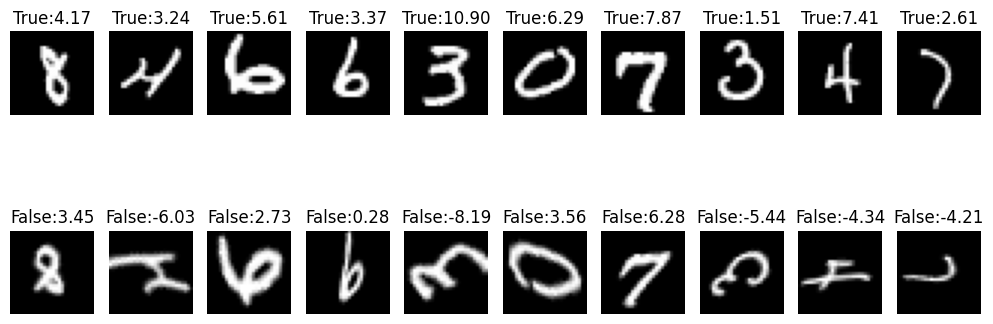

In [394]:
#test it on real data
#now test the convex regularizer on some data
import matplotlib.pyplot as plt
import numpy as np
import torch
true_batch = next(iter(val_loader))[0].cuda()
false_batch = next(iter(val_loader_transformed))[0].cuda()
with torch.no_grad():
    plt.figure(figsize=(10, 5))

    true_batch = true_batch[:10]
    false_batch = false_batch[:10]
    true_scores = energy_conf(true_batch).cpu().numpy()
    false_scores = energy_conf(false_batch).cpu().numpy()

    for i in range(10):
        plt.subplot(2, 10, i + 1)
        plt.imshow(true_batch[i].squeeze().cpu(), cmap='gray')
        plt.axis('off')
        plt.title('True'+ ':{:.2f}'.format(true_scores[i]))
        plt.subplot(2, 10, i + 11)
        plt.imshow(false_batch[i].squeeze().cpu(), cmap='gray')
        plt.axis('off')
        plt.title('False' + ':{:.2f}'.format(false_scores[i]))
    plt.tight_layout()


In [165]:
 energy_conf.map_func = lambda x: x

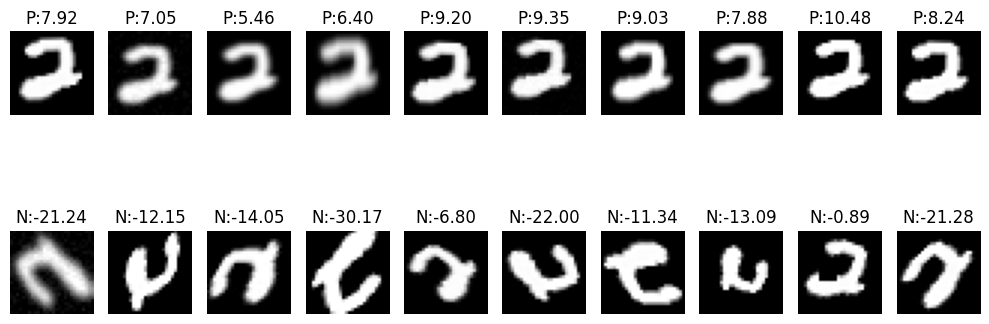

In [166]:
#test negative sample module
import matplotlib.pyplot as plt
import numpy as np
batch = next(iter(val_loader))
batch[0] =torch.stack([batch[0][0] for _ in range(batch[0].shape[0])], dim=0)

negative_samples = negative_sampling_module((batch[0].cuda(), batch[1].cuda()))
batch = batch[0].cuda()
# Assuming the first element is the image
#filter those from negative samples that were not transformed
positive_samples = (negative_samples[0][negative_samples[1]>=0], negative_samples[1][negative_samples[1]>=0])
negative_samples = (negative_samples[0][negative_samples[1]<0], negative_samples[1][negative_samples[1]<0])
batch = positive_samples[0]


with torch.no_grad():
    negative_scores = energy_conf(negative_samples[0].cuda())
    positive_scores = energy_conf(batch)
    plt.figure(figsize=(10, 5))
    for i in range(10):
        plt.subplot(2, 10, i + 1)
        plt.imshow(batch[i].squeeze().cpu(), cmap='gray')
        plt.axis('off')
        plt.title('P' + ':{:.2f}'.format(positive_scores[i].item()))
        plt.subplot(2, 10, i + 11)
        plt.imshow(negative_samples[0][i].squeeze().cpu(), cmap='gray')
        plt.axis('off')
        plt.title('N' + ':{:.2f}'.format(negative_scores[i].item()))
    plt.tight_layout()



Epoch 5:  26%|██▌       | 121/469 [14:01<40:19,  0.14it/s, v_num=561, train_loss_step=0.128, val_acc=0.943, val_loss=0.149, train_loss_epoch=0.141]


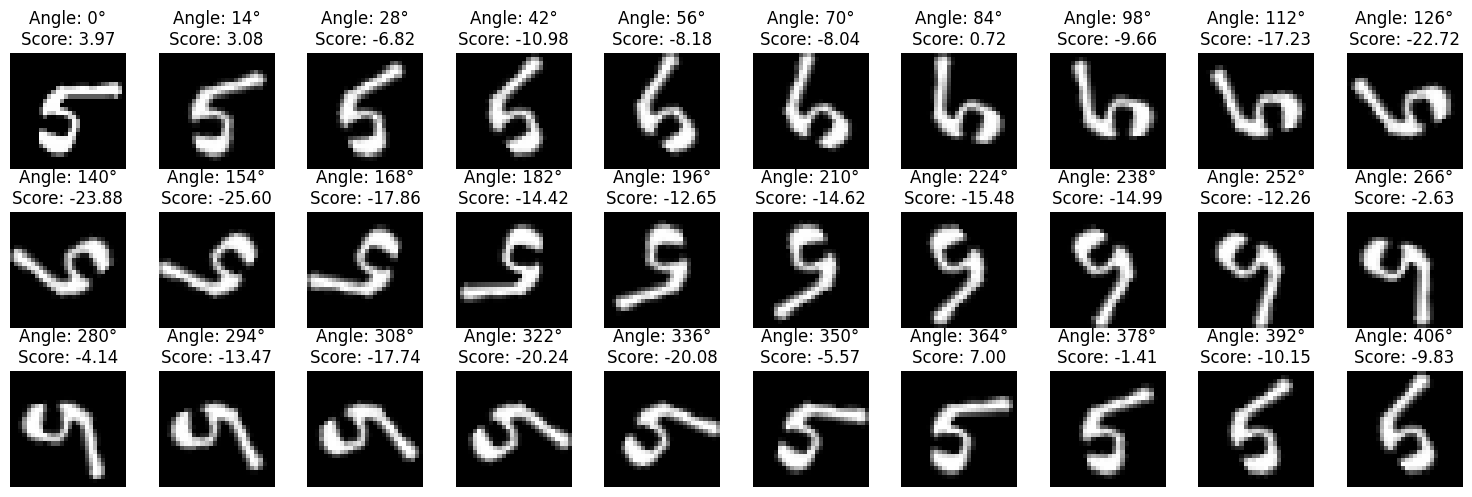

In [167]:
#take a random digit and rotate it by 30 increments
import random
import numpy as np
import torchvision.transforms as transforms
random_image= next(iter(train_loader))[0][0].cuda()
transformed_images= []

for i in range(30):
    angle = i * 14  # 30 increments of 12 degrees each
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomRotation((angle, angle),interpolation=transforms.InterpolationMode.BILINEAR, expand=False, center=None),
        transforms.ToTensor()
    ])
    transformed_images.append(transform(random_image).unsqueeze(0))
transformed_images = torch.cat(transformed_images, dim=0).cuda()
scores = energy_conf(transformed_images)

fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for i in range(30):
    axes[i // 10, i % 10].imshow(transformed_images[i].squeeze().cpu(), cmap='gray')
    axes[i // 10, i % 10].set_title(f'Angle: {i * 14}°\nScore: {scores[i].item():.2f}')
    axes[i // 10, i % 10].axis('off')
plt.tight_layout()
plt.show()

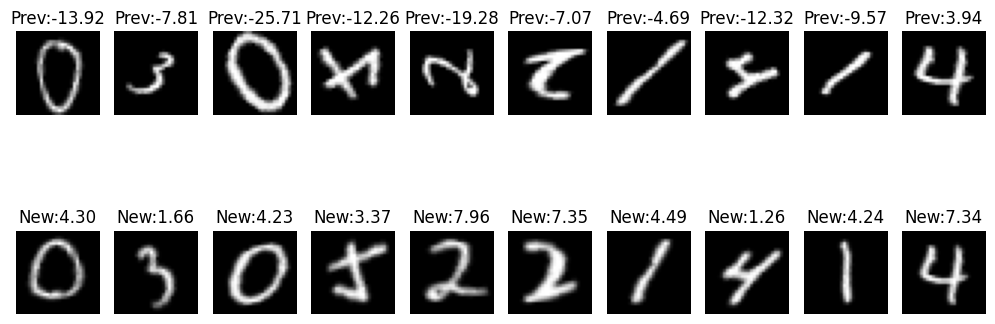

In [205]:
#optimize random image
random_indixes = np.random.choice(len(dataset_val_transformed), size=10, replace=False)
random_images = [dataset_val_transformed[i][0] for i in random_indixes]
random_images = torch.stack(random_images, dim=0).cuda()
with torch.no_grad():
    res = di_high_sample_count.optimize(problem_energy_pred_conf, random_images, y=None)
    score_prev = energy_conf(random_images).cpu().numpy()
    # Apply the transformation and get

    output = problem_energy_pred_conf.transform(random_images, res[0])
    score_new = energy_conf(output).cpu().numpy()
    plt.figure(figsize=(10, 5))
    for i in range(10):
        plt.subplot(2, 10, i + 1)
        plt.imshow(random_images[i].squeeze().cpu(), cmap='gray')
        plt.axis('off' )
        plt.title('Prev' + f':{score_prev[i]:.2f}')
        plt.subplot(2, 10, i + 11)
        plt.imshow(output[i].squeeze().cpu(), cmap='gray')
        plt.axis('off')
        plt.title('New' + f':{score_new[i]:.2f}')
    plt.tight_layout()


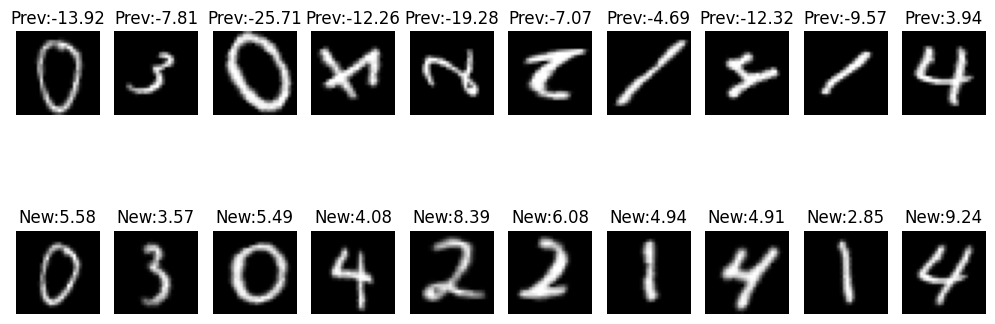

In [210]:
with torch.no_grad():
    res = di_high_sample_count.optimize(problem_energy_pred_conf, random_images, y=None)
    score_prev = energy_conf(random_images).cpu().numpy()
    # Apply the transformation and get

    output = problem_energy_pred_conf.transform(random_images, res[0])
    score_new = energy_conf(output).cpu().numpy()
    plt.figure(figsize=(10, 5))
    for i in range(10):
        plt.subplot(2, 10, i + 1)
        plt.imshow(random_images[i].squeeze().cpu(), cmap='gray')
        plt.axis('off' )
        plt.title('Prev' + f':{score_prev[i]:.2f}')
        plt.subplot(2, 10, i + 11)
        plt.imshow(output[i].squeeze().cpu(), cmap='gray')
        plt.axis('off')
        plt.title('New' + f':{score_new[i]:.2f}')
    plt.tight_layout()

In [ ]:
#optimize random image
random_images = transformed_images[:10]
with torch.no_grad():
    res = di_high_sample_count.optimize(problem_nn_pytorch, random_images, y=None)
    score_prev = energy_conf(random_images).cpu().numpy()
    # Apply the transformation and get

    output = problem_nn_pytorch.transform(random_images, res[0])
    score_new = energy_conf(output).cpu().numpy()
    plt.figure(figsize=(10, 5))
    for i in range(10):
        plt.subplot(2, 10, i + 1)
        plt.imshow(random_images[i].squeeze().cpu(), cmap='gray')
        plt.axis('off')
        plt.title('Prev' + f':{score_prev[i]:.2f}')
        plt.subplot(2, 10, i + 11)
        plt.imshow(output[i].squeeze().cpu(), cmap='gray')
        plt.axis('off')
        plt.title('New' + f':{score_new[i]:.2f}')
    plt.tight_layout()


In [ ]:
#now test the convex regularizer on some data
import matplotlib.pyplot as plt
import numpy as np
import torch
true_batch = next(iter(val_loader))[0].cuda()
false_batch = next(iter(val_loader_transformed))[0].cuda()
convex_regularizer.eval().cuda()
with torch.no_grad():
    plt.figure(figsize=(10, 5))

    true_batch = true_batch[:10]
    false_batch = false_batch[:10]
    true_scores = convex_regularizer(true_batch).cpu().numpy()
    false_scores = convex_regularizer(false_batch).cpu().numpy()

    for i in range(10):
        plt.subplot(2, 10, i + 1)
        plt.imshow(true_batch[i].squeeze().cpu(), cmap='gray')
        plt.axis('off')
        plt.title('True'+ ':{:.2f}'.format(true_scores[i,0]))
        plt.subplot(2, 10, i + 11)
        plt.imshow(false_batch[i].squeeze().cpu(), cmap='gray')
        plt.axis('off')
        plt.title('False' + ':{:.2f}'.format(false_scores[i,0]))
    plt.tight_layout()


In [ ]:
#now test the convex regularizer on some data
import matplotlib.pyplot as plt
import numpy as np
import torch
true_batch = next(iter(val_loader))[0].cuda()
false_batch = next(iter(val_loader_transformed))[0].cuda()
convex_regularizer.eval().cuda()
with torch.no_grad():
    plt.figure(figsize=(10, 5))

    true_batch = true_batch[:10]
    false_batch = false_batch[:10]
    #calc elbo now
    true_scores = vae.elbo(true_batch).cpu().numpy()
    false_scores = vae.elbo(false_batch).cpu().numpy()

    for i in range(10):
        plt.subplot(2, 10, i + 1)
        plt.imshow(true_batch[i].squeeze().cpu(), cmap='gray')
        plt.axis('off')
        plt.title('True'+ ':{:.2f}'.format(true_scores[i]))
        plt.subplot(2, 10, i + 11)
        plt.imshow(false_batch[i].squeeze().cpu(), cmap='gray')
        plt.axis('off')
        plt.title('False' + ':{:.2f}'.format(false_scores[i]))
    plt.tight_layout()


In [ ]:
problem_vae = TransformationProblem(
    conf,
    transform_seq,
    consolidate_method="consolidate_simple"
)

In [ ]:
conf(next(iter(train_loader))[0].cuda()).shape

In [ ]:
conf.beta=100

In [ ]:
evaluate_conf(model, di, problem_vae, test_loader, max_batch_override=1000)

In [ ]:
sdfgds

In [ ]:


from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence,PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
nn_pytorch = PerClassKNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings).cpu(), y=torch.tensor(classes).cpu())
nn_pytorch.cuda()


conf_split = PredictedSplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.0)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

evaluate_conf(model, di, problem_nn_pytorch, test_loader)

In [ ]:
dsfgd

In [ ]:


from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence,PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
nn_pytorch = PerClassKNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings_sampled).cpu(), y=torch.tensor(classes_sampled).cpu())
nn_pytorch.cuda()


conf_split = PredictedSplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.00001)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

evaluate_conf(model, di, problem_nn_pytorch, test_loader)

In [ ]:


from confidence.direct.prob_based import EntropyConfidence
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence,NNGuideSplitConfidence


class one_confidence(nn.Module):
    def __init__(self):
        super().__init__()
        self.EnergyConfidence = EnergyConfidence()

    def forward(self, x,y=None):
        return torch.ones_like(x)[:,0]

class one_confidence2(nn.Module):
    def __init__(self):
        super().__init__()
        self.EnergyConfidence = EnergyConfidence()

    def forward(self, x,y=None):
        return self.EnergyConfidence(x,y)

conf_split = NNGuideSplitConfidence(one_confidence2(), k=3)
conf_split.fit((torch.tensor(embeddings_sampled).cpu(), torch.tensor(logits_sampled).cpu()))
conf_split.cuda()
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
nn_pytorch.save("test.pth")
nn_pytorch.load("test.pth")

In [ ]:
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
problem_nn_pytorch.calculate_error(data.cuda(), torch.zeros(data.shape[0],5).cuda())

In [ ]:
from confidence.unsupervised.classic.lle import LLEResidualConfidence

lle_conf = LLEResidualConfidence()
lle_conf.fit(torch.tensor(embeddings_sampled).cpu())
lle_conf.cuda()
conf_split = SplitConfidence(lle_conf, EnergyConfidence(), mult=False, b=0.0)
conf_mod_lle = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
from confidence.unsupervised.classic.openmax import OpenMaxConfidence
from confidence.control.split import PredictedSplitConfidence

lle_conf = OpenMaxConfidence()
lle_conf.fit(torch.tensor(embeddings_sampled).cuda(), y=torch.tensor(classes_sampled).cuda())
lle_conf.cuda()
conf_split = PredictedSplitConfidence(lle_conf, EnergyConfidence(), mult=False, b=0.0)
conf_mod_lle = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
#extract logits from train
logits2 = []
classes2 = []
for batch in train_loader:
    logits_batch = model(batch[0].cuda())
    logits2.append(logits_batch.detach().cpu().numpy())
    classes2.append(batch[1].detach().cpu().numpy())
logits2 = np.vstack(logits2)
classes2 = np.hstack(classes2)

In [ ]:
from confidence.unsupervised.classic.openmax import OpenMaxConfidence
from confidence.control.split import PredictedSplitConfidence

lle_conf2 = OpenMaxConfidence()
lle_conf2.fit(torch.tensor(logits2).cuda(), y=torch.tensor(classes2).cuda())
lle_conf2.cuda()
conf_split = PredictedSplitConfidence(lle_conf,lle_conf2, mult=False, a=0.0,b=1.0)
conf_mod_lle = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
from confidence.unsupervised.classic.openmax3 import OpenMaxConfidenceNumpy as OpenMaxConfidence2
from confidence.control.split import PredictedSplitConfidence
import tqdm
lle_conf3 = OpenMaxConfidence2()
lle_conf3.fit(torch.tensor(logits2).cuda(), y=torch.tensor(classes2).cuda())
lle_conf3.cuda()

conf_mod_lle = SinglePassConfidence(model, lle_conf3)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di_no_grad.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
    break
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
from confidence.unsupervised.classic.openmax3 import OpenMaxConfidence as OpenMaxConfidence3
from confidence.control.split import PredictedSplitConfidence
import tqdm
lle_conf3 = OpenMaxConfidence3()
lle_conf3.fit(torch.tensor(logits2).cuda(), y=torch.tensor(classes2).cuda())
lle_conf3.cuda()

conf_mod_lle = SinglePassConfidence(model, lle_conf3)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di_no_grad.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
from confidence.unsupervised.classic.nn import NNDistanceConfidence

nearest_neighbor_confidence = NNDistanceConfidence(index_type="ivfpq", number_of_neighbors=3)
nearest_neighbor_confidence.fit(torch.tensor(embeddings_sampled).cpu(), y=torch.tensor(classes_sampled).cpu())
nearest_neighbor_confidence.cuda()
conf_split = SplitConfidence(nearest_neighbor_confidence, EnergyConfidence(), mult=False, b=0.0)
conf_mod = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:

from confidence.unsupervised.classic.gmm import GaussianMixtureConfidence

gmm_conf = GaussianMixtureConfidence(n_components=10, covariance_type="full")
gmm_conf.fit(embeddings_sampled)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:

from confidence.unsupervised.classic.isolation import HardIsolationForestConfidence

gmm_conf = HardIsolationForestConfidence(contamination=0.01,max_features=10)
gmm_conf.fit(embeddings)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:


from confidence.unsupervised.classic.trust_score import TrustScoreTorchConfidence

gmm_conf = TrustScoreTorchConfidence()
gmm_conf.device = "cuda"
gmm_conf.fit(torch.tensor(embeddings_sampled).cuda(),torch.tensor(classes_sampled).cuda())
gmm_conf.cuda()
conf_split = PredictedSplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target)

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:


from confidence.unsupervised.classic.kde import KDEConfidence

gmm_conf = KDEConfidence(bandwidth=0.2, kernel="gaussian")
gmm_conf.fit(embeddings_sampled)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:

from confidence.unsupervised.classic.osvm import OCSVMPredictiveConfidence

gmm_conf = OCSVMPredictiveConfidence(nu=0.01)
gmm_conf.fit(embeddings_sampled)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
import confidence.unsupervised.classic.pca
import importlib

importlib.reload(confidence.unsupervised.classic.pca)
from confidence.unsupervised.classic.pca import PCATorchConfidence

gmm_conf = PCATorchConfidence(n_components=32)
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:




from confidence.unsupervised.classic.gaussian import ImageGaussianConfidence

gmm_conf = ImageGaussianConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:


from confidence.unsupervised.classic.dice import DICEConfidence


gmm_conf = DICEConfidence(model,percentile=0.95)
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:


from confidence.unsupervised.classic.dice import DICEConfidence


gmm_conf = DICEConfidence(model,percentile=0.01)
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
gmm_conf = LOFTorchConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
from confidence.unsupervised.classic.mahalanobis_relative import RelativeMahalanobisConfidence

gmm_conf = RelativeMahalanobisConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
torch.cuda.empty_cache()

In [ ]:
from confidence.unsupervised.classic.pyood_wrapper import MahalanobisConfidence

gmm_conf = MahalanobisConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:

from confidence.unsupervised.classic.mtc import ManifoldTangentConfidence

gmm_conf = ManifoldTangentConfidence(n_components=128,n_clusters=50)
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:

from confidence.control.classify import ClassifyingConfidence
from confidence.unsupervised.classic.VIM import ViMTorchConfidence
gmm_conf = SHETorchConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = ClassifyingConfidence(gmm_conf,index=1,index_confidence=0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:

from confidence.control.classify import ClassifyingConfidence
from confidence.unsupervised.classic.VIM import ViMTorchConfidence
gmm_conf = ViMTorchConfidence(model.eval(),n_dim=64,use_energy=True)
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = ClassifyingConfidence(gmm_conf,index=1,index_confidence=0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
import confidence.unsupervised.ml.autoencoder
import importlib

importlib.reload(confidence.unsupervised.ml.autoencoder)
from confidence.unsupervised.ml.autoencoder import BasicAutoencoderConfidence

encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = BasicAutoencoderConfidence(encoder_lin, decoder_lin,trainer_kwargs={"max_epochs": 5},dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
import confidence.unsupervised.ml.autoencoder
import importlib

importlib.reload(confidence.unsupervised.ml.autoencoder)
from confidence.unsupervised.ml.autoencoder import ConditionalAutoencoderConfidence

encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(26, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = ConditionalAutoencoderConfidence(encoder_lin, decoder_lin,num_classes=10,trainer_kwargs={"max_epochs": 5},dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = PredictedSplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:


from confidence.unsupervised.ml.deepsvd import DeepSVDDConfidence

encoder_lin_deep = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 128,bias=False),
    nn.LeakyReLU(),
    nn.Linear(128, 128,bias=False),
    nn.LeakyReLU(),
    nn.Linear(128, 16,bias=False)
).cuda()
gmm_conf = DeepSVDDConfidence(encoder_lin_deep,objective="one-class",trainer_kwargs={"max_epochs": 5},dataloader_kwargs={"batch_size": 128},weight_decay=0.001)
gmm_conf.cuda()
gmm_conf.fit(torch.tensor(embeddings).cuda()).cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
from confidence.unsupervised.ml.vae import VAEConfidence
import confidence.unsupervised.ml.autoencoder
import importlib

importlib.reload(confidence.unsupervised.ml.autoencoder)


encoder_lin2 = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
).cuda()

class VAEEncoder(torch.nn.Module):
    def __init__(self,model,indim=128,outdim=16):
        super(VAEEncoder, self).__init__()
        self.model = model
        self.lin1= nn.Linear(indim, outdim)
        self.lin2 = nn.Linear(indim, outdim)
    def forward(self, x):
        x = self.model(x)
        return self.lin1(x), self.lin2(x)

encoder_lin2 = VAEEncoder(encoder_lin2).cuda()




decoder_lin2 = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = VAEConfidence(encoder_lin2, decoder_lin2,latent_dim=16,mode="elbo",beta=0.1,
                         trainer_kwargs={"max_epochs": 15},
                         dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
from confidence.unsupervised.ml.flow import FlowConfidence
import normflows as nf
# Define 2D Gaussian base distribution
base = nf.distributions.base.DiagGaussian(128)

# Define list of flows
num_layers = 2
flows = []
for i in range(num_layers):
    # Neural network with two hidden layers having 64 units each
    # Last layer is initialized by zeros making training more stable
    param_map = nf.nets.MLP([64, 128, 128, 128], init_zeros=True)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(2, mode='swap'))

flow = nf.NormalizingFlow(base, flows)

gmm_conf = FlowConfidence(flow, decoder_lin2,
                         trainer_kwargs={"max_epochs": 20},
                         dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()


In [ ]:
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ASHConfidence

gmm_conf = ASHConfidence(model[:-5],model[-5:],variant="ash-s",percentile=0.85)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
model[:-3]

In [ ]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ReActConfidence

gmm_conf = ReActConfidence(model[:-2],model[-2:],threshold=3.0)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
dual_output_model2 = ModelInputWrapper(model[:-2],'10',flatten=True).eval()

In [ ]:
knn_conf = KNNConfidence(k=3,metric="cosine")
knn_conf.fit(torch.tensor(embeddings_sampled).cuda(), y=torch.tensor(classes_sampled).cuda())


In [ ]:
conf = SplitConfidence(knn_conf, EnergyConfidence(), mult=True, b=0.0)

In [ ]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ReActConfidence

gmm_conf = ReActConfidence(dual_output_model2,model[-2:],threshold=3.0,index_feat=1,confidence=conf)




problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ReActConfidence

gmm_conf = SinglePassConfidence(dual_ouput_model,conf,index=1)

problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
from utils.sampling import BatchNegativeSampler
from utils.sampling_strategy import GaussianSamplingStrategyLatent
import confidence.supervised.ml.contrastive_autoencoder
import importlib

importlib.reload(confidence.supervised.ml.contrastive_autoencoder)
importlib.reload(confidence.unsupervised.unsupervised_base)

from confidence.supervised.ml.contrastive_autoencoder import ContrastiveAutoencoder

encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = ContrastiveAutoencoder(encoder_lin, decoder_lin,trainer_kwargs={"max_epochs": 10},dataloader_kwargs={"batch_size": 128},distance_type="l2",mode="reconstruction").cuda()
sampling_strategy = GaussianSamplingStrategyLatent()
gmm_conf.negative_sampling_module =BatchNegativeSampler(sampling_strategy)


gmm_conf.fit(torch.tensor(embeddings).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
gmm_conf.distance_type = "l2"
conf_split = PredictedSplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

In [ ]:
from utils.sampling import BatchNegativeSampler
from utils.sampling_strategy import GaussianSamplingStrategyLatent
import confidence.supervised.ml.contrastive_autoencoder
import importlib

importlib.reload(confidence.supervised.ml.contrastive_autoencoder)
importlib.reload(confidence.unsupervised.unsupervised_base)

from confidence.supervised.ml.contrastive_autoencoder import ContrastiveAutoencoder

encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = ContrastiveAutoencoder(encoder_lin, decoder_lin,trainer_kwargs={"max_epochs": 10},dataloader_kwargs={"batch_size": 128},distance_type="l2",mode="reconstruction").cuda()
sampling_strategy = GaussianSamplingStrategyLatent()
gmm_conf.negative_sampling_module =BatchNegativeSampler(sampling_strategy)


gmm_conf.fit(torch.tensor(embeddings).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
gmm_conf.distance_type = "l2"
conf_split = PredictedSplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')